<a href="https://colab.research.google.com/github/dokunoale/chagas/blob/feature%2FLSTM/notebooks/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone --branch feature/LSTM --single-branch https://github.com/dokunoale/chagas.git
%cd chagas
# Carica librerie installate
!pip install wfdb -q
!pip install gdown -q

# Aggiungi solo la root del progetto (src)
import sys
sys.path.append('/content/chagas/src')

# Importa tutto dai moduli
from preprocessing import tf_dataset_loader
from models import utils

# Importa simboli specifici (se vuoi)
from preprocessing.tf_dataset_loader import *
from models.utils import *

Cloning into 'chagas'...
remote: Enumerating objects: 142, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 142 (delta 27), reused 21 (delta 16), pack-reused 99 (from 1)
Receiving objects: 100% (142/142), 37.29 KiB | 569.00 KiB/s, done.
Resolving deltas: 100% (60/60), done.
/content/chagas
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 125.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.0 which is incompatible.
dask-cudf-cu12 25.2.2 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.0 which is incompatible.
cudf-cu12 25.2.1 requires pandas

In [2]:
import gdown

url = "https://drive.google.com/file/d/1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC/view?usp=drive_link"
gdown.download(url, "dataset.zip", quiet=False, fuzzy=True)
!unzip -q dataset.zip -d ./dataset

Downloading...
From (original): https://drive.google.com/uc?id=1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC
From (redirected): https://drive.google.com/uc?id=1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC&confirm=t&uuid=fa5dfd52-4149-4666-8ea8-9607d0fc41de
To: /content/chagas/dataset.zip
100%|██████████| 623M/623M [00:14<00:00, 42.3MB/s]


In [3]:
#Carichiamo su array np
X_train_positive, y_train_positive = tf_dataset_loader.load_dataset('/content/chagas/dataset/big_splitted_dataset/train/positives')
X_train_negative, y_train_negative = tf_dataset_loader.load_dataset('/content/chagas/dataset/big_splitted_dataset/train/negatives')

X_val_positive, y_val_positive = tf_dataset_loader.load_dataset('/content/chagas/dataset/big_splitted_dataset/val/positives')
X_val_negative, y_val_negative = tf_dataset_loader.load_dataset('/content/chagas/dataset/big_splitted_dataset/val/negatives')

X_test_positive, y_test_positive = tf_dataset_loader.load_dataset('/content/chagas/dataset/big_splitted_dataset/test/positives')
X_test_negative, y_test_negative = tf_dataset_loader.load_dataset('/content/chagas/dataset/big_splitted_dataset/test/negatives')


In [4]:
X_train, y_train = tf_dataset_loader.concatenate_and_shuffle((X_train_positive, y_train_positive), (X_train_negative, y_train_negative))
X_val, y_val = tf_dataset_loader.concatenate_and_shuffle((X_val_positive, y_val_positive), (X_val_negative, y_val_negative))
X_test, y_test = tf_dataset_loader.concatenate_and_shuffle((X_test_positive, y_test_positive), (X_test_negative, y_test_negative))

In [5]:
print(f"TRAIN SHAPE: {X_train.shape} - VALIDATION SHAPE: {X_val.shape} - TEST SHAPE: {X_test.shape}")

TRAIN SHAPE: (7855, 2800, 12) - VALIDATION SHAPE: (1122, 2800, 12) - TEST SHAPE: (2245, 2800, 12)


In [6]:
y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

In [7]:
from models import build_LSTM
from models.build_LSTM import build_ecg_lstm_model

from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC
from sklearn.utils import class_weight

In [8]:
model = build_LSTM.build_ecg_lstm_model(dropout_rate=0.5)

#compiliamo il modello
model.compile(optimizer='adam',
              loss=BinaryCrossentropy(),
              metrics=['accuracy', AUC(name='auc')])

#addestriamo il modello
callback = make_callback("LSTM")

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=50,
                    batch_size=32,
                    callbacks=callback)

Epoch 1/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.6040 - auc: 0.6449 - loss: 0.6548
Epoch 1: val_auc improved from -inf to 0.66925, saving model to 1_CNN_best_model.h5


246/246 ━━━━━━━━━━━━━━━━━━━━ 92s 345ms/step - accuracy: 0.6040 - auc: 0.6449 - loss: 0.6548 - val_accuracy: 0.6212 - val_auc: 0.6692 - val_loss: 0.6374 - learning_rate: 0.0010
Epoch 2/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.6327 - auc: 0.6737 - loss: 0.6401
Epoch 2: val_auc did not improve from 0.66925
246/246 ━━━━━━━━━━━━━━━━━━━━ 88s 357ms/step - accuracy: 0.6327 - auc: 0.6736 - loss: 0.6401 - val_accuracy: 0.6221 - val_auc: 0.6517 - val_loss: 0.6505 - learning_rate: 0.0010
Epoch 3/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.6281 - auc: 0.6700 - loss: 0.6427
Epoch 3: val_auc improved from 0.66925 to 0.67514, saving model to 1_CNN_best_model.h5


246/246 ━━━━━━━━━━━━━━━━━━━━ 88s 359ms/step - accuracy: 0.6281 - auc: 0.6700 - loss: 0.6427 - val_accuracy: 0.6408 - val_auc: 0.6751 - val_loss: 0.6381 - learning_rate: 0.0010
Epoch 4/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.6372 - auc: 0.6857 - loss: 0.6317
Epoch 4: val_auc improved from 0.67514 to 0.68497, saving model to 1_CNN_best_model.h5


246/246 ━━━━━━━━━━━━━━━━━━━━ 89s 362ms/step - accuracy: 0.6372 - auc: 0.6857 - loss: 0.6317 - val_accuracy: 0.6337 - val_auc: 0.6850 - val_loss: 0.6407 - learning_rate: 0.0010
Epoch 5/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.6363 - auc: 0.6843 - loss: 0.6286
Epoch 5: val_auc improved from 0.68497 to 0.68831, saving model to 1_CNN_best_model.h5


246/246 ━━━━━━━━━━━━━━━━━━━━ 89s 360ms/step - accuracy: 0.6363 - auc: 0.6843 - loss: 0.6286 - val_accuracy: 0.6266 - val_auc: 0.6883 - val_loss: 0.6315 - learning_rate: 0.0010
Epoch 6/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.6284 - auc: 0.6794 - loss: 0.6366
Epoch 6: val_auc did not improve from 0.68831
246/246 ━━━━━━━━━━━━━━━━━━━━ 89s 362ms/step - accuracy: 0.6284 - auc: 0.6794 - loss: 0.6366 - val_accuracy: 0.6408 - val_auc: 0.6839 - val_loss: 0.6293 - learning_rate: 0.0010
Epoch 7/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.6367 - auc: 0.6803 - loss: 0.6359
Epoch 7: val_auc did not improve from 0.68831
246/246 ━━━━━━━━━━━━━━━━━━━━ 90s 364ms/step - accuracy: 0.6367 - auc: 0.6804 - loss: 0.6358 - val_accuracy: 0.6132 - val_auc: 0.6765 - val_loss: 0.6350 - learning_rate: 0.0010
Epoch 8/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.6385 - auc: 0.6872 - loss: 0.6313
Epoch 8: val_auc did not improve from 0.68831
246/246 ━━━━━━━━━━━━━━━━━━━━

246/246 ━━━━━━━━━━━━━━━━━━━━ 90s 365ms/step - accuracy: 0.6525 - auc: 0.7074 - loss: 0.6190 - val_accuracy: 0.6275 - val_auc: 0.6903 - val_loss: 0.6325 - learning_rate: 5.0000e-04
Epoch 10/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.6572 - auc: 0.7133 - loss: 0.6166
Epoch 10: val_auc improved from 0.69034 to 0.69448, saving model to 1_CNN_best_model.h5


246/246 ━━━━━━━━━━━━━━━━━━━━ 90s 365ms/step - accuracy: 0.6571 - auc: 0.7133 - loss: 0.6166 - val_accuracy: 0.6355 - val_auc: 0.6945 - val_loss: 0.6225 - learning_rate: 5.0000e-04
Epoch 11/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.6543 - auc: 0.7218 - loss: 0.6076
Epoch 11: val_auc did not improve from 0.69448
246/246 ━━━━━━━━━━━━━━━━━━━━ 90s 365ms/step - accuracy: 0.6543 - auc: 0.7218 - loss: 0.6077 - val_accuracy: 0.6408 - val_auc: 0.6872 - val_loss: 0.6298 - learning_rate: 5.0000e-04
Epoch 12/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.6522 - auc: 0.7106 - loss: 0.6135
Epoch 12: val_auc improved from 0.69448 to 0.69862, saving model to 1_CNN_best_model.h5


246/246 ━━━━━━━━━━━━━━━━━━━━ 90s 366ms/step - accuracy: 0.6522 - auc: 0.7106 - loss: 0.6135 - val_accuracy: 0.6542 - val_auc: 0.6986 - val_loss: 0.6254 - learning_rate: 5.0000e-04
Epoch 13/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.6555 - auc: 0.7163 - loss: 0.6072
Epoch 13: val_auc did not improve from 0.69862
246/246 ━━━━━━━━━━━━━━━━━━━━ 90s 365ms/step - accuracy: 0.6555 - auc: 0.7163 - loss: 0.6072 - val_accuracy: 0.6399 - val_auc: 0.6758 - val_loss: 0.6380 - learning_rate: 5.0000e-04
Epoch 14/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.6597 - auc: 0.7167 - loss: 0.6077
Epoch 14: val_auc did not improve from 0.69862
246/246 ━━━━━━━━━━━━━━━━━━━━ 90s 364ms/step - accuracy: 0.6596 - auc: 0.7167 - loss: 0.6077 - val_accuracy: 0.6569 - val_auc: 0.6953 - val_loss: 0.6275 - learning_rate: 5.0000e-04
Epoch 15/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.6662 - auc: 0.7269 - loss: 0.6050
Epoch 15: val_auc did not improve from 0.69862
246/246 ━━

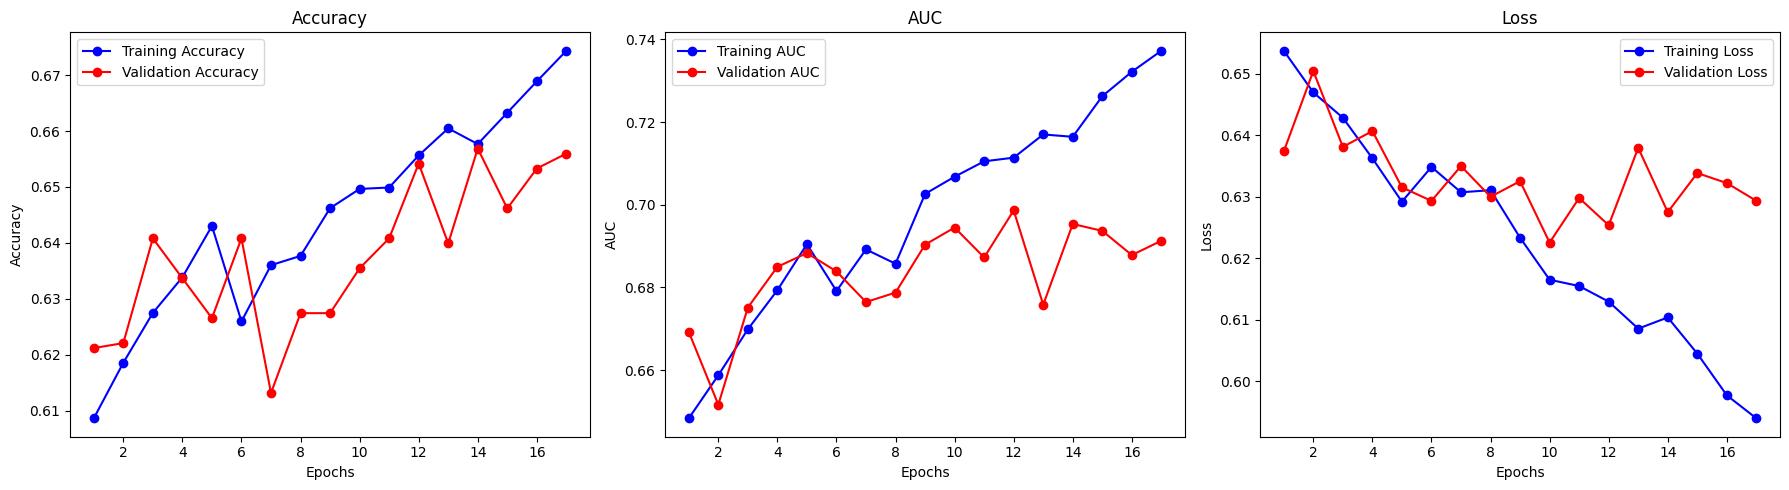

In [11]:
utils.plot_training_metrics(history)

In [12]:
#Facciamo le predizioni
y_pred_proba_val = model.predict(X_val).flatten()

#Troviamo la soglia ottimale
optimal_threshold = find_optimal_threshold(y_val, y_pred_proba_val)

# Applica soglia ottimale per binarizzare le predizioni
y_pred_proba_test = model.predict(X_test).flatten()
y_pred_binary = (y_pred_proba_test >= optimal_threshold).astype(int)

36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step
Soglia ottimale: 0.546
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step


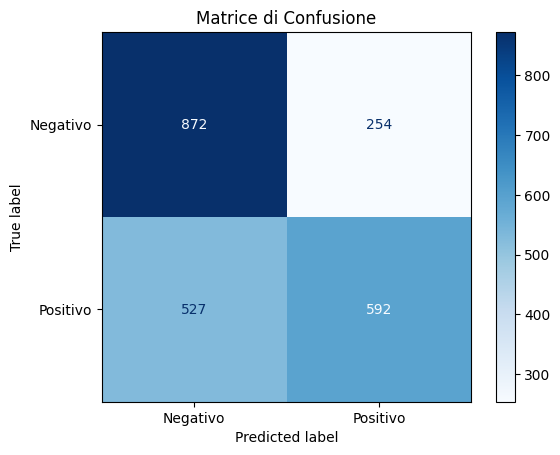

In [13]:
#Calcoliamo la matrice di confusione e la visualizziamo
cm = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm)

In [16]:
def find_threshold_for_min_recall(y_true, y_pred_proba, min_recall=0.75):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    valid_indices = [i for i, val in enumerate(tpr) if val >= min_recall]
    if not valid_indices:
        print("Nessuna soglia raggiunge la recall minima richiesta.")
        return None
    # Prendi la soglia con il più basso FPR tra quelli con recall >= min_recall
    best_idx = min(valid_indices, key=lambda i: fpr[i])
    threshold = thresholds[best_idx]
    print(f"Soglia con recall >= {min_recall}: {threshold:.3f}")
    return threshold


#Facciamo le predizioni
y_pred_proba_val = model.predict(X_val).flatten()

#Troviamo la soglia ottimale
optimal_threshold_min_rec = find_threshold_for_min_recall(y_val, y_pred_proba_val)

# Applica soglia ottimale per binarizzare le predizioni
y_pred_proba_test = model.predict(X_test).flatten()
y_pred_binary = (y_pred_proba_test >= optimal_threshold_min_rec).astype(int)

36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step
Soglia con recall >= 0.75: 0.437
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step


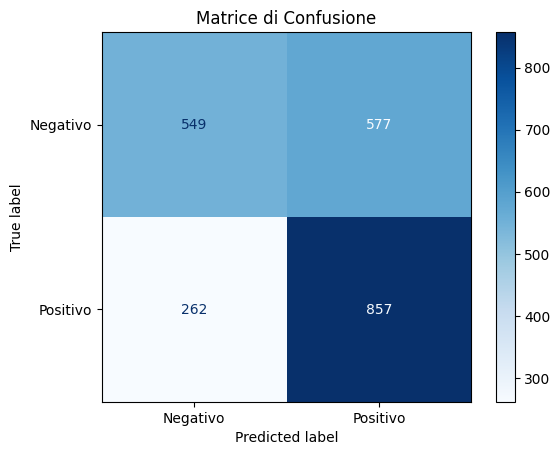

In [17]:
#Calcoliamo la matrice di confusione e la visualizziamo
cm = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm)

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
model_path = "/content/drive/MyDrive/chagas_models/LSTM_model.keras"
model.save(model_path)